In [1]:
%load_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt
import torch
import torchsde
from torchdyn.core import NeuralODE
from tqdm import tqdm

from torchcfm.conditional_flow_matching import *
from torchcfm.models import MLP
from torchcfm.utils import sample_8gaussians, sample_moons, torch_wrapper

savedir = "models/2d"
os.makedirs(savedir, exist_ok=True)

In [2]:
def plot_trajectories_sb(traj, legend=True):
    n = 2000
    plt.figure(figsize=(10, 10))
    plt.scatter(traj[0, :n, 0], traj[0, :n, 1], s=10, alpha=0.8, c="black")
    plt.scatter(traj[:, :n, 0], traj[:, :n, 1], s=0.4, alpha=0.1, c="olive")
    plt.scatter(traj[-1, :n, 0], traj[-1, :n, 1], s=4, alpha=1, c="blue")

    for i in range(5, 15):
        plt.plot(traj[:, i, 0], traj[:, i, 1], alpha=0.9, c="red")
    if legend:
        plt.legend([r"$p_0$", r"$p_t$", r"$p_1$", r"$X_t \mid X_0$"])
    plt.xticks([])
    plt.yticks([])
    plt.axis("off")

In [12]:
class EnergyModel(torch.nn.Module):
    def __init__(self, v):
        super().__init__()
        self.v = v
    def forward(self, x):
        t = x[:, -1]
        #one_over_two_sigma_t_squared = torch.clip(t / torch.clip(4 * (1 - t), min=1e-2), min=1e-2, max=1e-2)
        return ((self.v(x) - x[:, :-1]) ** 2).sum(-1)
class GradModel(torch.nn.Module):
    def __init__(self, action):
        super().__init__()
        self.action = action

    def forward(self, x):
        with torch.enable_grad():
            x = x.requires_grad_(True)
            grad = torch.autograd.grad(torch.sum(self.action(x)), x, create_graph=True)[0]
            return grad[:, :-1]

class MLP2(torch.nn.Module):
    def __init__(self, dim, out_dim=None, w=64, time_varying=False):
        super().__init__()
        self.time_varying = time_varying
        if out_dim is None:
            out_dim = dim
        self.net = torch.nn.Sequential(
            torch.nn.Linear(dim + (1 if time_varying else 0), w),
            torch.nn.ReLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, w),
            torch.nn.SiLU(),
            torch.nn.Linear(w, out_dim),
        )

    def forward(self, x):
        return self.net(x)

In [34]:
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
device = "cpu"
batch_size = 256
sigma = 0
dim = 2
#flow_model = MLP(dim=dim, time_varying=True, w=256)
#energy_model = EnergyModel(flow_model)
#model = GradModel(energy_model)
action = MLP2(dim=dim, out_dim=1, time_varying=True, w=256)
model = GradModel(action)
#score_model = MLP(dim=dim, time_varying=True, w=64)
optimizer = torch.optim.Adam(model.parameters(), 0.01)
FM = ConditionalFlowMatcher(sigma=sigma)
# FM = SchrodingerBridgeConditionalFlowMatcher(sigma=sigma)
eps = 1e-2

In [35]:
for i in tqdm(range(30000)):
    optimizer.zero_grad()
    x0 = torch.randn(batch_size,2)
    x1 = sample_8gaussians(batch_size)
    t, xt, ut, _ = FM.sample_location_and_conditional_flow(x0, x1, return_noise=True)
    vt = model(torch.cat([xt, t[:, None]], dim=-1))
    #vt = (xt + (1 - t[:,None]) * score_t) / torch.clip(t[:,None], min=eps)
    #true_score_t = (t[:,None] * ut - xt) / torch.clip(1 - t[:,None], min=eps)
    #pred_score_t = (t[:,None] * vt - xt) / torch.clip(1 - t[:,None], min=eps)
    flow_loss = torch.mean((vt - ut) ** 2)
    loss = flow_loss
    loss.backward()
    optimizer.step()

100%|██████████████████████████████████████████████████████████████| 30000/30000 [03:00<00:00, 166.34it/s]


In [36]:
torch.save(model, f"{savedir}/sf2m_v1.pt")

In [37]:
node = NeuralODE(torch_wrapper(model), solver="euler", sensitivity="adjoint", atol=1e-4, rtol=1e-4)
x0 = torch.randn(100,2)

#with torch.no_grad():
traj = node.trajectory(
    x0,
    t_span=torch.linspace(0, 1, 100, device=device),
)

In [38]:
from torch.distributions import MultivariateNormal

prior = MultivariateNormal(torch.zeros(dim, device=device), torch.eye(dim, device=device))


In [39]:
n_steps = 1000
dt = 1 / n_steps
x0 = torch.randn(1024,2)
traj_sde = [x0]
xt = x0
eps = 2e-2
logp = prior.log_prob(x0)
logp2 = prior.log_prob(x0)
for t in torch.linspace(0, 1, n_steps + 1):
    sigma_t_squared = (2 * (1 - t) / torch.clip(t, min=eps))
    # sigma_t = (2 (1 - t) / t) ** 0.5
    sigma_t = sigma_t_squared ** 0.5
    vt = model(torch.cat([xt, t.repeat(1024, 1)], dim=-1))
    # st is correct we checked
    st = 2 * vt - xt / torch.clip(t, min=1e-2)
    eps_t = torch.randn_like(xt)
    noise_t = sigma_t * eps_t * (dt ** 0.5)
    dxt = st * dt + noise_t
    xt = xt + dxt
    score_t = (t * vt - xt) / torch.clip(1 - t, min=eps)
    dlogp2 = ((-xt.shape[-1] / torch.clip(t, min=eps) * dt
              + (score_t * (-sigma_t_squared / 2 * score_t * dt + dxt * dt - xt / torch.clip(t, min=eps)) * dt).sum(-1))) 
    dlogp = ((-xt.shape[-1] / torch.clip(t, min=eps) 
              + (sigma_t_squared / 2 * score_t * score_t).sum(-1)) * dt
             + (score_t * noise_t).sum(-1))
    logp = logp + dlogp
    logp2 = logp2 + dlogp2
    traj_sde.append(xt)
traj_sde = torch.stack(traj_sde)

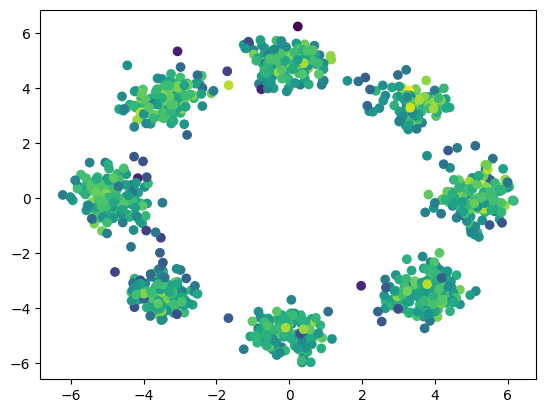

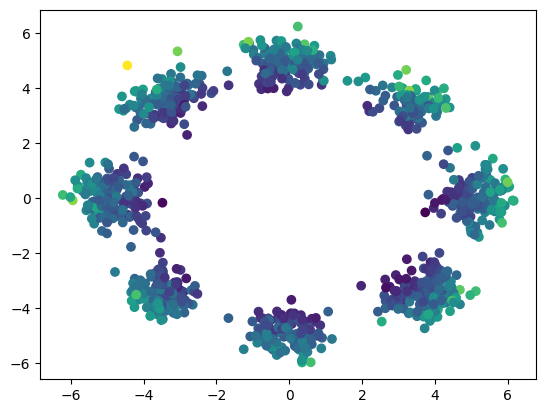

In [40]:
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp.detach())
plt.show()
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logp2.detach())

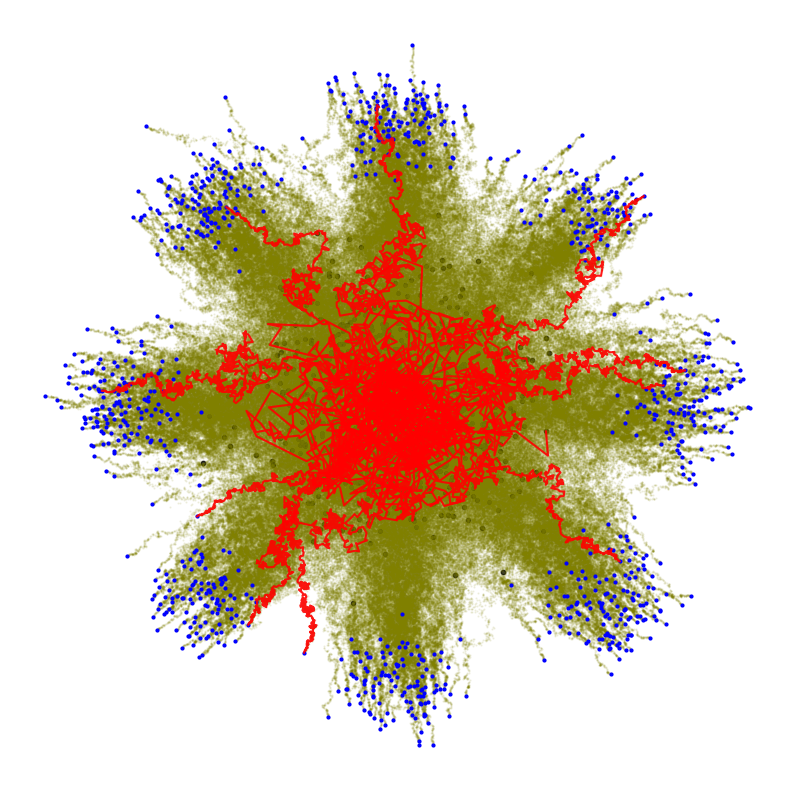

In [41]:
plot_trajectories_sb(traj_sde.detach().cpu().numpy(), legend=False)


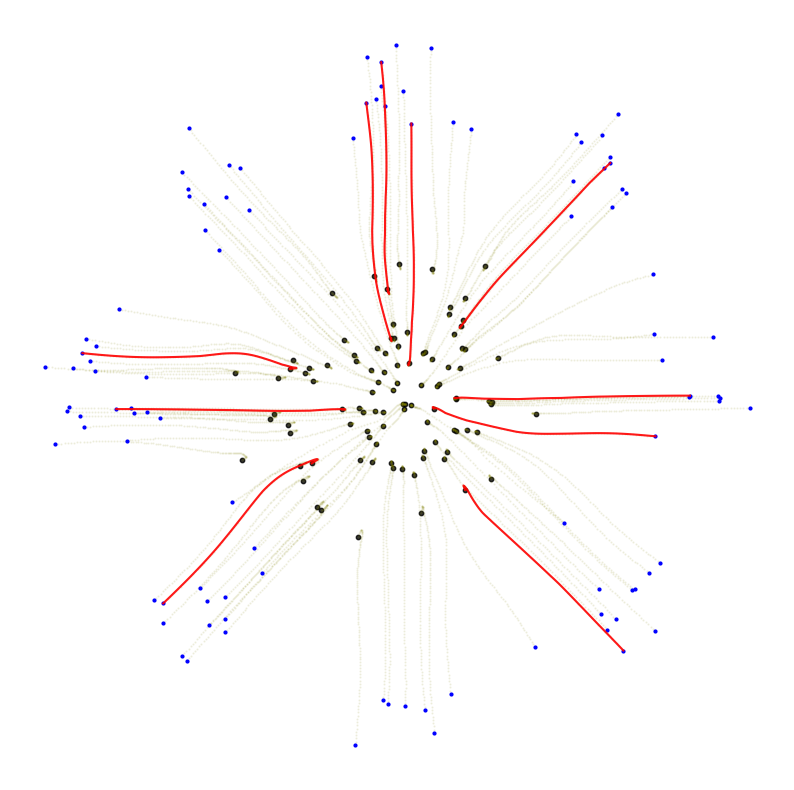

In [42]:
plot_trajectories_sb(traj.detach().cpu().numpy(), legend=False)


In [23]:
class torch_wrapper(torch.nn.Module):
    """Wraps model to torchdyn compatible format."""

    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, t, x, *args, **kwargs):
        return self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))


def exact_div_fn(u):
    """Accepts a function u:R^D -> R^D."""
    J = torch.func.jacrev(u)
    return lambda x, *args: torch.trace(J(x))


def div_fn_hutch_trace(u):
    def div_fn(x, eps):
        _, vjpfunc = torch.func.vjp(u, x)
        return (vjpfunc(eps)[0] * eps).sum()

    return div_fn


class cnf_wrapper(torch.nn.Module):
    """Wraps model to a torchdyn compatible CNF format.
    Appends an additional dimension representing the change in likelihood
    over time.
    """

    def __init__(self, model, likelihood_estimator="exact"):
        super().__init__()
        self.model = model
        self.div_fn, self.eps_fn = self.get_div_and_eps(likelihood_estimator)

    def get_div_and_eps(self, likelihood_estimator):
        if likelihood_estimator == "exact":
            return exact_div_fn, None
        if likelihood_estimator == "hutch_gaussian":
            return div_fn_hutch_trace, torch.randn_like
        if likelihood_estimator == "hutch_rademacher":

            def eps_fn(x):
                return torch.randint_like(x, low=0, high=2).float() * 2 - 1.0

            return div_fn_hutch_trace, eps_fn
        raise NotImplementedError(
            f"likelihood estimator {likelihood_estimator} is not implemented"
        )

    def forward(self, t, x, *args, **kwargs):
        t = t.squeeze()
        x = x[..., :-1]

        def vecfield(y):
            return self.model(torch.cat([y, t[None]]))

        if self.eps_fn is None:
            div = torch.vmap(self.div_fn(vecfield))(x)
        else:
            div = torch.vmap(self.div_fn(vecfield))(x, self.eps_fn(x))
        dx = self.model(torch.cat([x, t.repeat(x.shape[0])[:, None]], 1))
        return torch.cat([dx, div[:, None]], dim=-1)

In [24]:
cnf = NeuralODE(
    cnf_wrapper(model, likelihood_estimator="exact"), 
    atol=1e-3,
    rtol=1e-3,
    solver="dopri5", sensitivity="adjoint"
)

In [25]:

x1 = traj_sde[-1]
device = "cpu"
steps = 1
x1_with_ll = torch.cat([x1, torch.zeros(x1.shape[0], 1, device=device)], dim=-1)
x0_with_ll = cnf.trajectory(x1_with_ll, t_span=torch.linspace(1, 0, steps + 1, device=device))[
    -1
]
logprob = prior.log_prob(x0_with_ll[..., :-1]) + x0_with_ll[..., -1]

RuntimeError: You are attempting to call Tensor.requires_grad_() (or perhaps using torch.autograd.functional.* APIs) inside of a function being transformed by a functorch transform. This is unsupported, please attempt to use the functorch transforms (e.g. grad, vjp, jacrev, jacfwd, hessian) or call requires_grad_() outside of a function being transformed instead.

In [ ]:
logprob

In [ ]:
plt.scatter(traj_sde[-1][:,0].detach(), traj_sde[-1][:,1].detach(), c=logprob.detach())